In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels

Defaulting to user installation because normal site-packages is not writeable


In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

from scipy.stats import levene
from scipy.stats import shapiro
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import f_oneway

import statsmodels.api as sm
from statsmodels.formula.api import ols

In [10]:
df = pd.read_excel('Strikers_performance.xlsx')

print(df.head())

   Striker_ID Nationality    Footedness Marital Status  Goals Scored  \
0           1       Spain   Left-footed             No     17.483571   
1           2      France   Left-footed            Yes     14.308678   
2           3     Germany   Left-footed             No     18.238443   
3           4      France  Right-footed             No     22.615149   
4           5      France   Left-footed            Yes     13.829233   

     Assists  Shots on Target  Shot Accuracy  Conversion Rate  \
0  10.778533        34.795488       0.677836         0.166241   
1  13.728250        31.472436       0.544881         0.192774   
2   3.804297        25.417413       0.518180         0.160379   
3   9.688908        20.471443       0.599663         0.184602   
4   6.048072        29.887563       0.582982         0.105319   

   Dribbling Success  Movement off the Ball  Hold-up Play  Aerial Duels Won  \
0           0.757061              50.921924     71.806409         15.682532   
1           0.7968

In [11]:
print(df.shape)
print(df.columns)
print(df.info)

(500, 19)
Index(['Striker_ID', 'Nationality', 'Footedness', 'Marital Status',
       'Goals Scored', 'Assists', 'Shots on Target', 'Shot Accuracy',
       'Conversion Rate', 'Dribbling Success', 'Movement off the Ball',
       'Hold-up Play', 'Aerial Duels Won', 'Defensive Contribution',
       'Big Game Performance', 'Consistency', 'Penalty Success Rate',
       'Impact on Team Performance', 'Off-field Conduct'],
      dtype='object')
<bound method DataFrame.info of      Striker_ID Nationality    Footedness Marital Status  Goals Scored  \
0             1       Spain   Left-footed             No     17.483571   
1             2      France   Left-footed            Yes     14.308678   
2             3     Germany   Left-footed             No     18.238443   
3             4      France  Right-footed             No     22.615149   
4             5      France   Left-footed            Yes     13.829233   
..          ...         ...           ...            ...           ...   
495       

In [12]:
print(df.isnull().sum())

Striker_ID                    0
Nationality                   0
Footedness                    0
Marital Status                0
Goals Scored                  0
Assists                       0
Shots on Target               0
Shot Accuracy                 0
Conversion Rate               0
Dribbling Success             0
Movement off the Ball         6
Hold-up Play                  0
Aerial Duels Won              0
Defensive Contribution        0
Big Game Performance          2
Consistency                   0
Penalty Success Rate          5
Impact on Team Performance    0
Off-field Conduct             0
dtype: int64


In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [15]:
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [18]:
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [19]:
int_columns = [
    'Goals Scored',
    'Assists',
    'Shots on Target',
    'Movement off the Ball',
    'Hold-up Play',
    'Aerial Duels Won',
    'Defensive Contribution',
    'Big Game Performance',
    'Impact on Team Performance',
    'Off-field Conduct'
]

for col in int_columns:
    df[col] = df[col].astype(int)

In [20]:
print(df.describe().round(2))

       Striker_ID  Goals Scored  Assists  Shots on Target  Shot Accuracy  \
count      500.00        500.00   500.00           500.00         500.00   
mean       250.50         14.52     7.60            25.26           0.60   
std        144.48          4.91     2.96             7.08           0.10   
min          1.00          0.00     0.00             4.00           0.31   
25%        125.75         11.00     6.00            20.00           0.54   
50%        250.50         15.00     8.00            25.00           0.60   
75%        375.25         18.00     9.00            30.00           0.67   
max        500.00         34.00    15.00            43.00           0.92   

       Conversion Rate  Dribbling Success  Movement off the Ball  \
count           500.00             500.00                 500.00   
mean              0.20               0.70                  69.28   
std               0.05               0.10                  10.33   
min               0.05               0.40  

In [21]:
foot_percent = df['Footedness'].value_counts(normalize=True) * 100
print(foot_percent.round(2))

Footedness
Right-footed    53.4
Left-footed     46.6
Name: proportion, dtype: float64


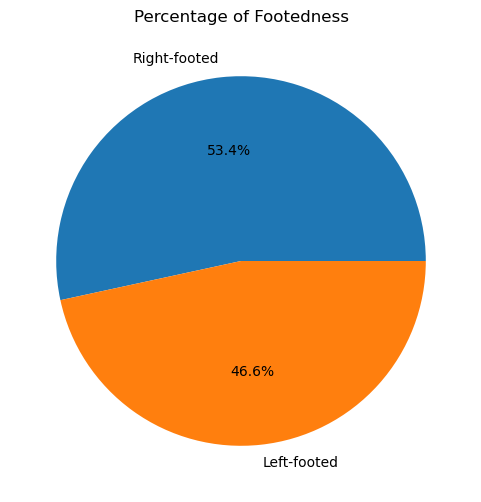

In [24]:
plt.figure(figsize=(6,6))
plt.pie(
    foot_percent,
    labels=foot_percent.index,
    autopct='%1.1f%%'
)
plt.title('Percentage of Footedness')
plt.show()

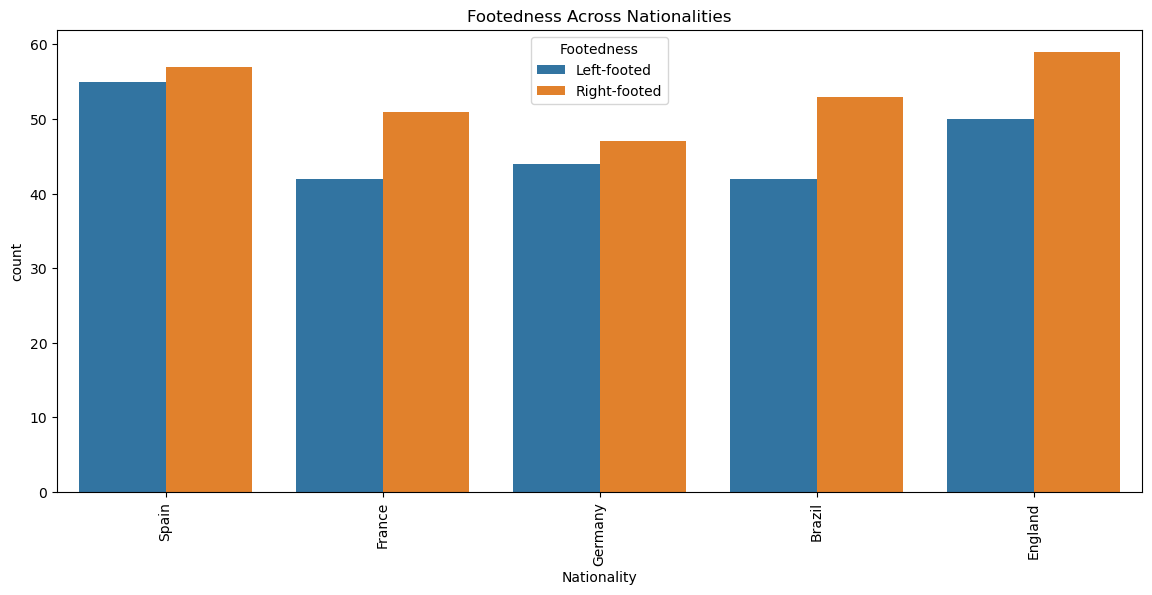

In [25]:
plt.figure(figsize=(14,6))
sns.countplot(data=df, x='Nationality', hue='Footedness')
plt.xticks(rotation=90)
plt.title('Footedness Across Nationalities')
plt.show()

In [26]:
avg_goals = df.groupby('Nationality')['Goals Scored'].mean()
print(avg_goals.sort_values(ascending=False))

Nationality
Brazil     15.315789
Spain      14.687500
France     14.408602
Germany    14.351648
England    13.899083
Name: Goals Scored, dtype: float64


In [27]:
conversion_rate = df.groupby('Footedness')['Conversion Rate'].mean()
print(conversion_rate)

Footedness
Left-footed     0.198086
Right-footed    0.200592
Name: Conversion Rate, dtype: float64


In [28]:
for nation in df['Nationality'].unique():
    stat, p = shapiro(df[df['Nationality']==nation]['Consistency'])
    print(nation, p)

Spain 0.6272529723742946
France 0.4209394625417563
Germany 0.9636214615848093
Brazil 0.730289122427942
England 0.9730417417840104


In [29]:
groups = [
    df[df['Nationality']==nation]['Consistency']
    for nation in df['Nationality'].unique()
]

stat, p = levene(*groups)

print('Levene Test P-value:', p)

Levene Test P-value: 0.8083990350934653


In [30]:
anova_result = f_oneway(*groups)
print(anova_result)

F_onewayResult(statistic=np.float64(1.527898429363593), pvalue=np.float64(0.19278675901599154))


In [31]:
print(shapiro(df['Hold-up Play']))
print(shapiro(df['Consistency']))

ShapiroResult(statistic=np.float64(0.9954325275369145), pvalue=np.float64(0.15094090394128723))
ShapiroResult(statistic=np.float64(0.9968719443391263), pvalue=np.float64(0.45127699414580213))


In [32]:
corr, p = pearsonr(df['Hold-up Play'], df['Consistency'])

print('Correlation:', corr)
print('P-value:', p)

Correlation: 0.14654573283554145
P-value: 0.0010146963053630732


In [33]:
X = sm.add_constant(df['Hold-up Play'])
y = df['Consistency']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Consistency   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     10.93
Date:                Mon, 25 May 2026   Prob (F-statistic):            0.00101
Time:                        12:29:51   Log-Likelihood:                 429.97
No. Observations:                 500   AIC:                            -855.9
Df Residuals:                     498   BIC:                            -847.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.6548      0.027     24.031   

In [34]:
df['Total contribution score'] = (
    df['Goals Scored'] +
    df['Assists'] +
    df['Shots on Target'] +
    df['Dribbling Success'] +
    df['Aerial Duels Won'] +
    df['Defensive Contribution'] +
    df['Big Game Performance'] +
    df['Consistency']
)

In [35]:
le = LabelEncoder()

df['Footedness'] = le.fit_transform(df['Footedness'])
df['Marital Status'] = le.fit_transform(df['Marital Status'])

In [36]:
df = pd.get_dummies(df, columns=['Nationality'], drop_first=True)

In [37]:
cluster_data = df.drop('Striker_ID', axis=1)

In [38]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(cluster_data)
    wcss.append(kmeans.inertia_)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

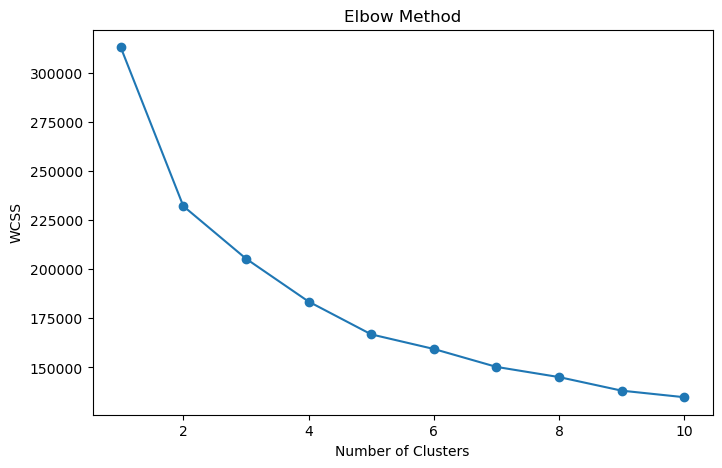

In [39]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [40]:
kmeans = KMeans(n_clusters=2, random_state=42)

df['Clusters'] = kmeans.fit_predict(cluster_data)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [41]:
cluster_avg = df.groupby('Clusters')['Total contribution score'].mean()
print(cluster_avg)

Clusters
0    101.846088
1    123.350913
Name: Total contribution score, dtype: float64


In [42]:
df['Strikers types'] = df['Clusters'].map({
    0: 'Best strikers',
    1: 'Regular strikers'
})

In [43]:
df.drop('Clusters', axis=1, inplace=True)

In [44]:
df['Strikers types'] = df['Strikers types'].map({
    'Best strikers': 1,
    'Regular strikers': 0
})

In [45]:
X = df.drop(['Strikers types', 'Striker_ID'], axis=1)
y = df['Strikers types']

In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

In [48]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [49]:
y_pred = lr.predict(X_test)

In [50]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy * 100)

Accuracy: 96.0


In [51]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[55  1]
 [ 3 41]]


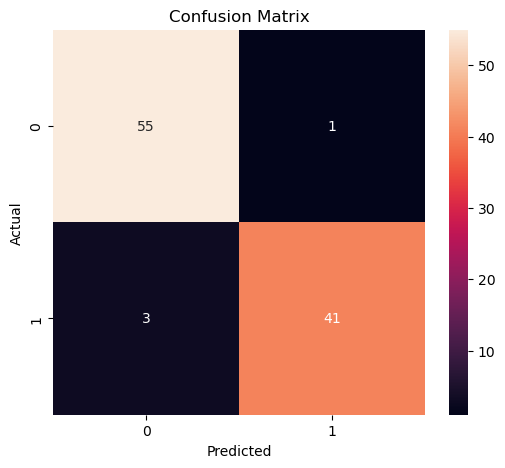

In [52]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()